# U-Net Training and Evaluation

This Colab notebook trains a 13-band U-Net on the reproducible CSV splits created in `02_unet_dataset_pipeline.ipynb`, selects the checkpoint with the best validation Dice score, and evaluates it exactly once on the held-out test split.

Before running this notebook, run the final export cells in notebook 02 so that `train_dataset.csv`, `val_dataset.csv`, and `test_dataset.csv` are present in the dataset directory on Google Drive. In Colab, choose **Runtime → Change runtime type → T4 GPU**.

In [1]:
# Install only packages that are not included in the standard Colab runtime.
!pip -q install rasterio

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Dataset

print('PyTorch:', torch.__version__)
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Mounted at /content/drive
PyTorch: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [10]:
import pandas as pd
from pathlib import Path

DATASET_DIR = Path('/content/SmallMinesDS')

csv_files = [
    DATASET_DIR / "train_dataset.csv",
    DATASET_DIR / "val_dataset.csv",
    DATASET_DIR / "test_dataset.csv"
]

In [11]:
OLD_ROOT = "/content/drive/MyDrive/datasets/SmallMinesDS"
NEW_ROOT = "/content/SmallMinesDS"

for csv_file in csv_files:
    df = pd.read_csv(csv_file)

    df["image_path"] = df["image_path"].str.replace(
        OLD_ROOT,
        NEW_ROOT,
        regex=False
    )

    df["mask_path"] = df["mask_path"].str.replace(
        OLD_ROOT,
        NEW_ROOT,
        regex=False
    )

    df.to_csv(csv_file, index=False)

    print(f"Updated {csv_file}")

Updated /content/SmallMinesDS/train_dataset.csv
Updated /content/SmallMinesDS/val_dataset.csv
Updated /content/SmallMinesDS/test_dataset.csv


In [12]:
df = pd.read_csv(DATASET_DIR / "train_dataset.csv")

print(df.head())

                                          image_path  \
0  /content/SmallMinesDS/2016/IMAGE/IMG_GH_1701_2...   
1  /content/SmallMinesDS/2016/IMAGE/IMG_GH_0682_2...   
2  /content/SmallMinesDS/2016/IMAGE/IMG_GH_0624_2...   
3  /content/SmallMinesDS/2016/IMAGE/IMG_GH_1106_2...   
4  /content/SmallMinesDS/2016/IMAGE/IMG_GH_1514_2...   

                                           mask_path  
0  /content/SmallMinesDS/2016/MASK/MASK_GH_1701_2...  
1  /content/SmallMinesDS/2016/MASK/MASK_GH_0682_2...  
2  /content/SmallMinesDS/2016/MASK/MASK_GH_0624_2...  
3  /content/SmallMinesDS/2016/MASK/MASK_GH_1106_2...  
4  /content/SmallMinesDS/2016/MASK/MASK_GH_1514_2...  


In [13]:
# Paths must match the location used when notebook 02 exported the CSV split files.
DATASET_DIR = Path('/content/SmallMinesDS')
OUTPUT_DIR = Path('/content/drive/MyDrive/ecowatch-model/experiments/unet_v1')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATASET_DIR / 'train_dataset.csv'
VAL_CSV = DATASET_DIR / 'val_dataset.csv'
TEST_CSV = DATASET_DIR / 'test_dataset.csv'

for split_file in (TRAIN_CSV, VAL_CSV, TEST_CSV):
    if not split_file.exists():
        raise FileNotFoundError(f'Missing {split_file}. Run notebook 02 through the CSV export cells first.')

# Adjust these values to fit the Colab GPU. Lower BATCH_SIZE to 4 if you see an out-of-memory error.
SEED = 42
BATCH_SIZE = 8
NUM_WORKERS = 2
EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
THRESHOLD = 0.5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print(f'Device: {DEVICE}; outputs: {OUTPUT_DIR}')

Device: cuda; outputs: /content/drive/MyDrive/ecowatch-model/experiments/unet_v1


In [14]:
class SmallMinesDataset(Dataset):
    """Reads 13-band Sentinel-2 images and binary mining masks from paired TIFF paths."""

    def __init__(self, csv_path):
        self.samples = pd.read_csv(csv_path)
        required_columns = {'image_path', 'mask_path'}
        if not required_columns.issubset(self.samples.columns):
            raise ValueError(f'{csv_path} must contain {required_columns}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        row = self.samples.iloc[index]
        with rasterio.open(row.image_path) as src:
            image = src.read().astype(np.float32)  # (bands, height, width)

        # Per-band normalization preserves the relative scale within each Sentinel-2 band.
        band_min = image.min(axis=(1, 2), keepdims=True)
        band_max = image.max(axis=(1, 2), keepdims=True)
        image = (image - band_min) / np.maximum(band_max - band_min, 1e-6)

        with rasterio.open(row.mask_path) as src:
            mask = src.read(1).astype(np.float32)
        mask = (mask > 0).astype(np.float32)[None, ...]

        return torch.from_numpy(image), torch.from_numpy(mask)

train_dataset = SmallMinesDataset(TRAIN_CSV)
val_dataset = SmallMinesDataset(VAL_CSV)
test_dataset = SmallMinesDataset(TEST_CSV)

loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

image, mask = train_dataset[0]
print(f'Train/validation/test: {len(train_dataset)}/{len(val_dataset)}/{len(test_dataset)}')
print(f'Image shape: {tuple(image.shape)}, mask shape: {tuple(mask.shape)}')

Train/validation/test: 3416/427/427
Image shape: (13, 128, 128), mask shape: (1, 128, 128)


In [15]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.layers(x)


class UNet(nn.Module):
    def __init__(self, in_channels=13, out_channels=1, features=(32, 64, 128, 256)):
        super().__init__()
        self.down_blocks = nn.ModuleList()
        self.up_transpose = nn.ModuleList()
        self.up_blocks = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        current_channels = in_channels
        for feature in features:
            self.down_blocks.append(DoubleConv(current_channels, feature))
            current_channels = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        current_channels = features[-1] * 2
        for feature in reversed(features):
            self.up_transpose.append(nn.ConvTranspose2d(current_channels, feature, kernel_size=2, stride=2))
            self.up_blocks.append(DoubleConv(feature * 2, feature))
            current_channels = feature

        self.output = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for down_block in self.down_blocks:
            x = down_block(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        for up, up_block, skip in zip(self.up_transpose, self.up_blocks, reversed(skips)):
            x = up(x)
            if x.shape[-2:] != skip.shape[-2:]:
                x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
            x = up_block(torch.cat((skip, x), dim=1))
        return self.output(x)

model = UNet().to(DEVICE)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Trainable parameters: 7,765,921


In [16]:
def dice_score_from_logits(logits, targets, threshold=THRESHOLD, epsilon=1e-7):
    predictions = (torch.sigmoid(logits) >= threshold).float()
    predictions = predictions.flatten(1)
    targets = targets.flatten(1)
    intersection = (predictions * targets).sum(dim=1)
    return ((2 * intersection + epsilon) / (predictions.sum(dim=1) + targets.sum(dim=1) + epsilon)).mean()


def iou_score_from_logits(logits, targets, threshold=THRESHOLD, epsilon=1e-7):
    predictions = (torch.sigmoid(logits) >= threshold).float()
    predictions = predictions.flatten(1)
    targets = targets.flatten(1)
    intersection = (predictions * targets).sum(dim=1)
    union = predictions.sum(dim=1) + targets.sum(dim=1) - intersection
    return ((intersection + epsilon) / (union + epsilon)).mean()


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5, epsilon=1e-7):
        super().__init__()
        self.bce_weight = bce_weight
        self.epsilon = epsilon
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        probabilities = torch.sigmoid(logits)
        probabilities = probabilities.flatten(1)
        targets = targets.flatten(1)
        intersection = (probabilities * targets).sum(dim=1)
        dice_loss = 1 - ((2 * intersection + self.epsilon) / (probabilities.sum(dim=1) + targets.sum(dim=1) + self.epsilon)).mean()
        return self.bce_weight * bce + (1 - self.bce_weight) * dice_loss


criterion = BCEDiceLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
scaler = GradScaler(enabled=DEVICE.type == 'cuda')
BEST_MODEL_PATH = OUTPUT_DIR / 'best_model.pt'

/tmp/ipykernel_799/2178903177.py:38: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=DEVICE.type == 'cuda')


In [19]:
def run_epoch(loader, training):
    model.train(training)
    total_loss = total_dice = total_iou = 0.0

    for images, masks in loader:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(training):
            with autocast(enabled=DEVICE.type == 'cuda'):
                logits = model(images)
                loss = criterion(logits, masks)

            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item()
        total_dice += dice_score_from_logits(logits.detach(), masks).item()
        total_iou += iou_score_from_logits(logits.detach(), masks).item()

    size = len(loader)
    return {'loss': total_loss / size, 'dice': total_dice / size, 'iou': total_iou / size}


history = []
best_val_dice = -float('inf')

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(train_loader, training=True)
    with torch.no_grad():
        val_metrics = run_epoch(val_loader, training=False)

    scheduler.step(val_metrics['dice'])
    row = {'epoch': epoch, **{f'train_{key}': value for key, value in train_metrics.items()}, **{f'val_{key}': value for key, value in val_metrics.items()}}
    history.append(row)

    if val_metrics['dice'] > best_val_dice:
        best_val_dice = val_metrics['dice']
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(), 'val_dice': best_val_dice, 'config': {'in_channels': 13, 'threshold': THRESHOLD}}, BEST_MODEL_PATH)

    print(f"Epoch {epoch:02d}/{EPOCHS} | train loss {train_metrics['loss']:.4f}, Dice {train_metrics['dice']:.4f} | val loss {val_metrics['loss']:.4f}, Dice {val_metrics['dice']:.4f}, IoU {val_metrics['iou']:.4f}")

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
print(f'Best validation Dice: {best_val_dice:.4f}; checkpoint: {BEST_MODEL_PATH}')

/tmp/ipykernel_799/3789246024.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=DEVICE.type == 'cuda'):


Epoch 01/30 | train loss 0.3756, Dice 0.4943 | val loss 0.3529, Dice 0.4746, IoU 0.4071
Epoch 02/30 | train loss 0.3556, Dice 0.5174 | val loss 0.3729, Dice 0.4031, IoU 0.3414
Epoch 03/30 | train loss 0.3469, Dice 0.5403 | val loss 0.3308, Dice 0.5939, IoU 0.5293
Epoch 04/30 | train loss 0.3413, Dice 0.5528 | val loss 0.3323, Dice 0.5354, IoU 0.4701
Epoch 05/30 | train loss 0.3367, Dice 0.5674 | val loss 0.3652, Dice 0.4086, IoU 0.3424
Epoch 06/30 | train loss 0.3346, Dice 0.5659 | val loss 0.3262, Dice 0.7074, IoU 0.6449
Epoch 07/30 | train loss 0.3303, Dice 0.5939 | val loss 0.3253, Dice 0.6482, IoU 0.5873
Epoch 08/30 | train loss 0.3294, Dice 0.5944 | val loss 0.3233, Dice 0.6006, IoU 0.5366
Epoch 09/30 | train loss 0.3304, Dice 0.6021 | val loss 0.3238, Dice 0.6244, IoU 0.5611
Epoch 10/30 | train loss 0.3269, Dice 0.6027 | val loss 0.3191, Dice 0.6046, IoU 0.5413
Epoch 11/30 | train loss 0.3195, Dice 0.6096 | val loss 0.3160, Dice 0.6200, IoU 0.5575
Epoch 12/30 | train loss 0.3184,

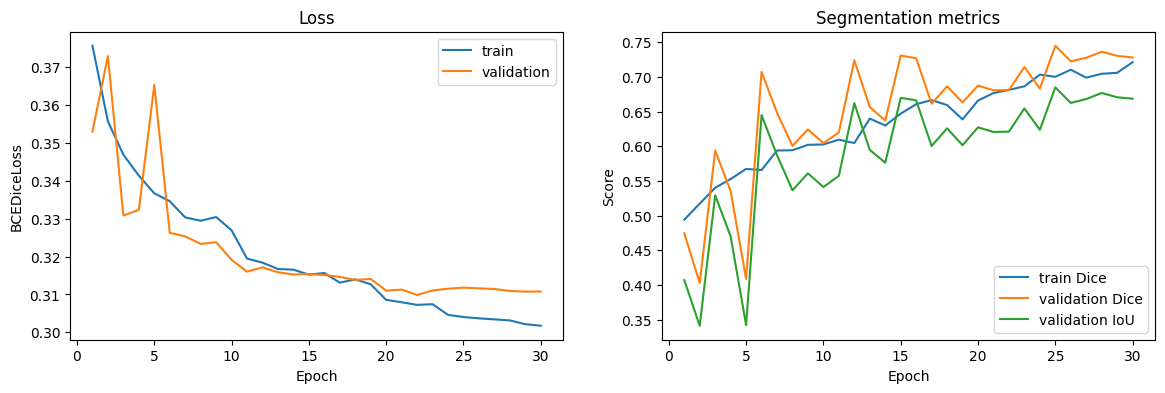

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train')
axes[0].plot(history_df['epoch'], history_df['val_loss'], label='validation')
axes[0].set(title='Loss', xlabel='Epoch', ylabel='BCEDiceLoss')
axes[0].legend()
axes[1].plot(history_df['epoch'], history_df['train_dice'], label='train Dice')
axes[1].plot(history_df['epoch'], history_df['val_dice'], label='validation Dice')
axes[1].plot(history_df['epoch'], history_df['val_iou'], label='validation IoU')
axes[1].set(title='Segmentation metrics', xlabel='Epoch', ylabel='Score')
axes[1].legend()
plt.show()

In [21]:
# Load only the best validation checkpoint before evaluating the untouched test split.
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

with torch.no_grad():
    test_metrics = run_epoch(test_loader, training=False)

test_results = {**test_metrics, 'best_epoch': checkpoint['epoch'], 'best_validation_dice': checkpoint['val_dice'], 'threshold': THRESHOLD}
with open(OUTPUT_DIR / 'test_metrics.json', 'w') as file:
    json.dump(test_results, file, indent=2)

print('Held-out test results')
for name, value in test_results.items():
    print(f'{name}: {value:.4f}' if isinstance(value, float) else f'{name}: {value}')

/tmp/ipykernel_799/3789246024.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=DEVICE.type == 'cuda'):


Held-out test results
loss: 0.3060
dice: 0.7056
iou: 0.6434
best_epoch: 25
best_validation_dice: 0.7450
threshold: 0.5000


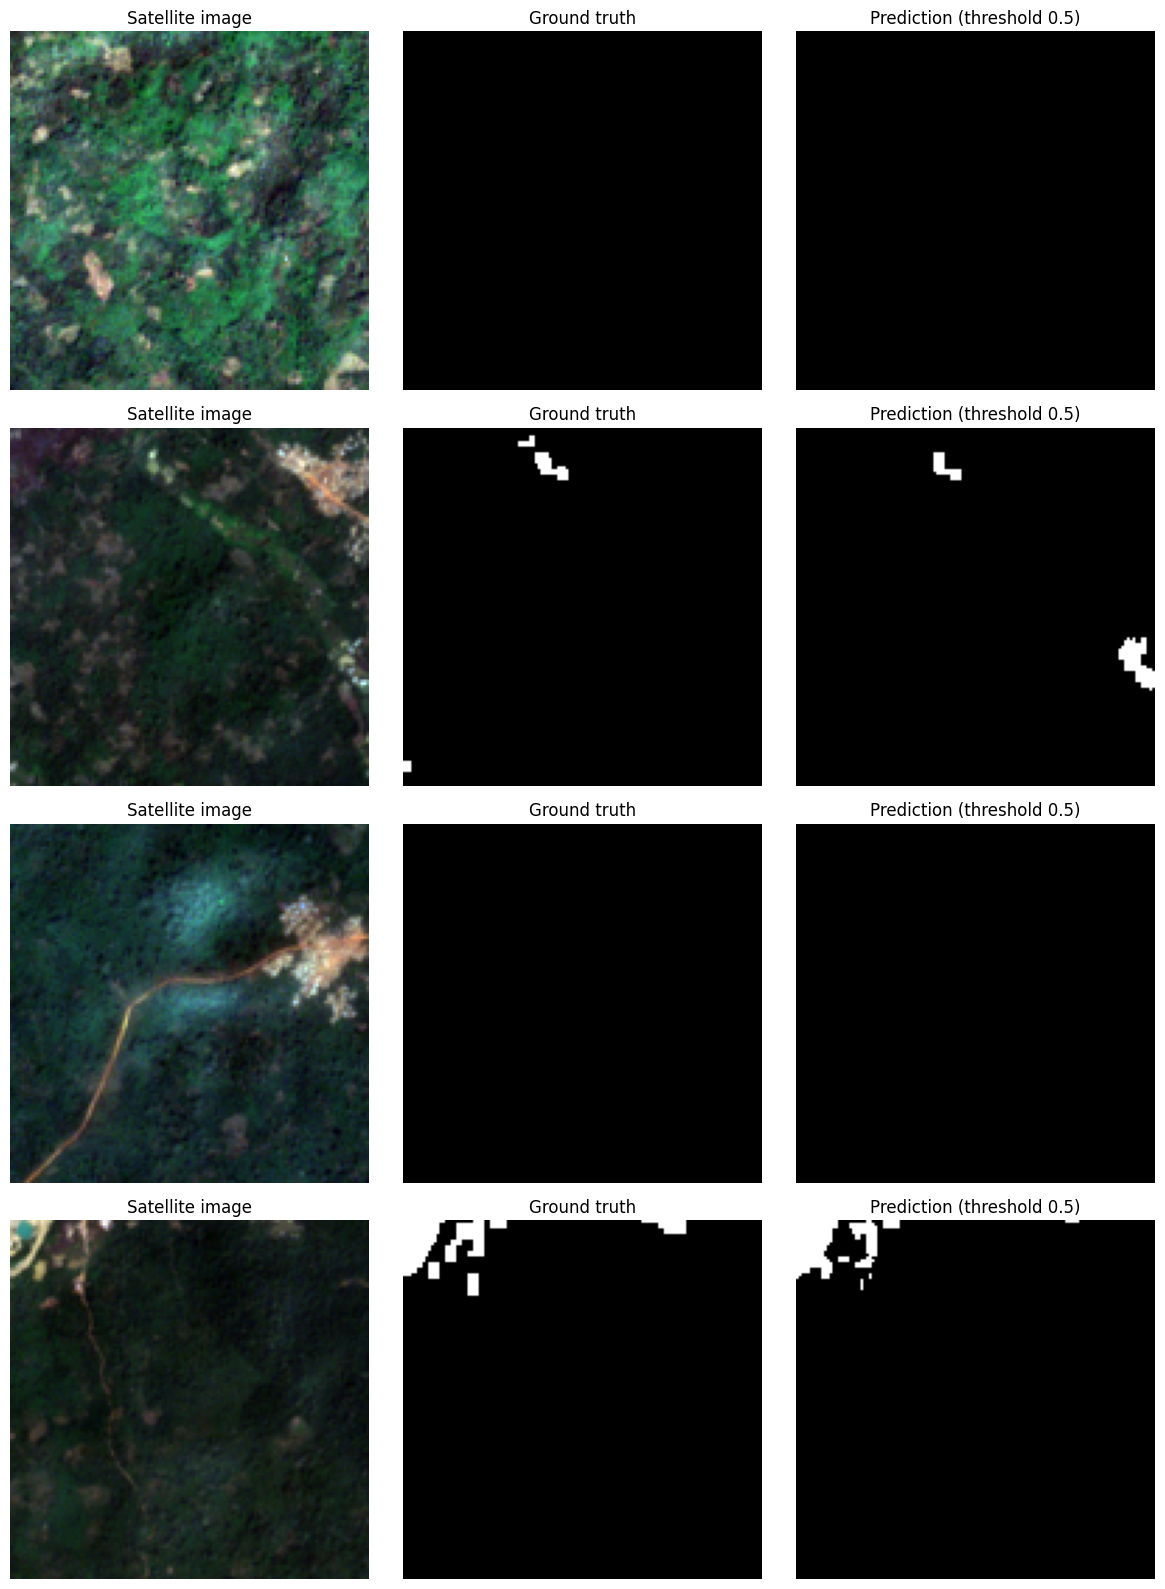

In [22]:
def show_predictions(dataset, count=4):
    indices = np.random.choice(len(dataset), size=min(count, len(dataset)), replace=False)
    fig, axes = plt.subplots(len(indices), 3, figsize=(12, 4 * len(indices)))
    axes = np.atleast_2d(axes)

    for row, index in enumerate(indices):
        image, target = dataset[index]
        with torch.no_grad():
            probability = torch.sigmoid(model(image.unsqueeze(0).to(DEVICE))).squeeze().cpu().numpy()

        # Sentinel-2 RGB uses blue, green, red as bands 0, 1, 2 in this dataset.
        rgb = image[[2, 1, 0]].permute(1, 2, 0).numpy()
        axes[row, 0].imshow(np.clip(rgb, 0, 1))
        axes[row, 0].set_title('Satellite image')
        axes[row, 1].imshow(target.squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[row, 1].set_title('Ground truth')
        axes[row, 2].imshow(probability >= THRESHOLD, cmap='gray', vmin=0, vmax=1)
        axes[row, 2].set_title(f'Prediction (threshold {THRESHOLD})')
        for axis in axes[row]:
            axis.axis('off')

    plt.tight_layout()

show_predictions(test_dataset)

## Saved artifacts

The experiment directory on Google Drive now contains `best_model.pt`, `training_history.csv`, and `test_metrics.json`. Keep the test CSV fixed; tune hyperparameters against validation metrics, retrain, and only then compare the final test metrics across experiments.